In [61]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Match plotting font scale from src/utils.py
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "legend.title_fontsize": 15,
})

In [62]:
data_tursio_simple = pd.read_csv("out_tursio/deepeval_tursio_results_simple.csv")
data_tursio_medium = pd.read_csv("out_tursio/deepeval_tursio_results_medium.csv")
data_tursio_hard = pd.read_csv("out_tursio/deepeval_tursio_results_hard.csv")

data_ppl_simple = pd.read_csv("out_ppl/ppl_simple/evaluation_results.csv")
data_ppl_medium = pd.read_csv("out_ppl/ppl_medium/evaluation_results.csv")
data_ppl_hard = pd.read_csv("out_ppl/ppl_hard/evaluation_results.csv")

data_gpt_simple = pd.read_csv("out_gpt/gpt_simple/evaluation_results.csv")
data_gpt_medium = pd.read_csv("out_gpt/gpt_medium/evaluation_results.csv")
data_gpt_hard = pd.read_csv("out_gpt/gpt_hard/evaluation_results.csv")

# filter for metric_name "Answer Relevancy"
data_tursio_simple_rel = data_tursio_simple[data_tursio_simple["metric_name"]=="Answer Relevancy"]
data_tursio_medium_rel = data_tursio_medium[data_tursio_medium["metric_name"]=="Answer Relevancy"]
data_tursio_hard_rel = data_tursio_hard[data_tursio_hard["metric_name"]=="Answer Relevancy"]

data_gpt_simple_rel = data_gpt_simple[data_gpt_simple["metric_name"]=="Answer Relevancy"]
data_gpt_medium_rel = data_gpt_medium[data_gpt_medium["metric_name"]=="Answer Relevancy"]
data_gpt_hard_rel = data_gpt_hard[data_gpt_hard["metric_name"]=="Answer Relevancy"]

data_ppl_simple_rel = data_ppl_simple[data_ppl_simple["metric_name"]=="Answer Relevancy"]
data_ppl_medium_rel = data_ppl_medium[data_ppl_medium["metric_name"]=="Answer Relevancy"]
data_ppl_hard_rel = data_ppl_hard[data_ppl_hard["metric_name"]=="Answer Relevancy"]

# print shape of each dataframe
print("Tursio Simple:", data_tursio_simple_rel.shape)
print("Tursio Medium:", data_tursio_medium_rel.shape)
print("Tursio Hard:", data_tursio_hard_rel.shape)
print("PPL Simple:", data_ppl_simple_rel.shape)
print("PPL Medium:", data_ppl_medium_rel.shape)
print("PPL Hard:", data_ppl_hard_rel.shape)
print("GPT Simple:", data_gpt_simple_rel.shape)
print("GPT Medium:", data_gpt_medium_rel.shape)
print("GPT Hard:", data_gpt_hard_rel.shape)


Tursio Simple: (45, 10)
Tursio Medium: (20, 10)
Tursio Hard: (38, 10)
PPL Simple: (60, 10)
PPL Medium: (20, 10)
PPL Hard: (38, 10)
GPT Simple: (52, 10)
GPT Medium: (20, 10)
GPT Hard: (38, 10)


In [63]:
# count metric_success True and False for each dataframe , and construct a summary dataframe for True perrcentage   
# finx this error: 
# AttributeError: 'DataFrame' object has no attribute 'append'

from scipy import stats

def build_summary( threshold=0.5):
    summary = pd.DataFrame(columns=["Dataset", "Total", "Success", "Answer Relevancy"] )
    ci_data = []
    for name, df in [("Tursio Simple", data_tursio_simple_rel), 
                    ("Tursio Medium", data_tursio_medium_rel), 
                    ("Tursio Hard", data_tursio_hard_rel), 
                    ("PPL Simple", data_ppl_simple_rel), 
                    ("PPL Medium", data_ppl_medium_rel), 
                    ("PPL Hard", data_ppl_hard_rel),
                    ("GPT Simple", data_gpt_simple_rel), 
                    ("GPT Medium", data_gpt_medium_rel), 
                    ("GPT Hard", data_gpt_hard_rel)]:
        
        total = df.shape[0]
        df["metric_success"] = df["metric_score"] >= threshold
        success = df[df["metric_success"]==True].shape[0]
        success_rate = success / total * 100
    
        if success_rate > 0:  # Only calculate CI for non-zero success rates
            # n = len(success_array)
            # successes = success_array.sum()
            ci = stats.binom.interval(0.95, total, success/total)
            ci_lower = ci[0] / total * 100
            ci_upper = ci[1] / total * 100
            error = success_rate - ci_lower
            
            ci_data.append({
                "Dataset": name,
                "Error": error
            })

        # Create a mapping of dataset to error
        ci_map = {row["Dataset"]: row["Error"] for row in ci_data}

        summary = pd.concat([summary, pd.DataFrame({"Dataset": [name], "Total": [total], "Success": [success], "Answer Relevancy": [success_rate]})], ignore_index=True)    

        # exttact a difficulty level from the dataset name
        summary["Difficulty"] = summary["Dataset"].apply(lambda x: x.split(" ")[1])
        # extract model name from the dataset name
        summary["Model"] = summary["Dataset"].apply(lambda x: x.split(" ")[0])  
        summary["Error"] = summary["Dataset"].map(ci_map)

    return summary

# buil histograms plot for each model and difficulty level
from scipy.stats import chi2_contingency

def run_stats_tests(summary):
    for difficulty in ["Simple", "Medium", "Hard"]:
        tursio_data = summary[(summary["Model"]=="Tursio") & (summary["Difficulty"]==difficulty)]
        gpt_data = summary[(summary["Model"]=="GPT") & (summary["Difficulty"]==difficulty)]
        ppl_data = summary[(summary["Model"]=="PPL") & (summary["Difficulty"]==difficulty)]

        ## Tursio vs GPT
        print (f"---- {difficulty} ----")
        contingency_table = [[tursio_data["Success"].values[0], tursio_data["Total"].values[0] - tursio_data["Success"].values[0]], 
                                [gpt_data["Success"].values[0], gpt_data["Total"].values[0] - gpt_data["Success"].values[0]]]
        chi2, p, dof, ex = chi2_contingency(contingency_table)
        alpha = 0.05
        if p < alpha:
            print(f"The difference between Tursio and GPT for {difficulty} difficulty is statistically significant (p = {p:.4f}).")
        else:
            print(f"The difference between Tursio and GPT for {difficulty} difficulty is not statistically significant (p = {p:.4f}).")     

    ## Tursio vs PPL
        contingency_table = [[tursio_data["Success"].values[0], tursio_data["Total"].values[0] - tursio_data["Success"].values[0]], 
                                [ppl_data["Success"].values[0], ppl_data["Total"].values[0] - ppl_data["Success"].values[0]]]
        chi2, p, dof, ex = chi2_contingency(contingency_table)
        alpha = 0.05
        if p < alpha:
            print(f"The difference between Tursio and PPL for {difficulty} difficulty is statistically significant. (p = {p:.4f})")
        else:
            print(f"The difference between Tursio and PPL for {difficulty} difficulty is not statistically significant (p = {p:.4f}).")


def plot_summary(summary):
    # set figure size
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=summary, x="Difficulty", y="Answer Relevancy", hue="Model")
    plt.ylim(0, 115)
    plt.title("Answer Relevancy Success Rate by Model and Difficulty Level", fontsize=16)
    plt.xlabel("Difficulty", fontsize=15)
    plt.ylabel("Answer Relevancy", fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    # Add error bars
    for patch, error in zip(ax.patches, summary["Error"].values):
        x_pos = patch.get_x() + patch.get_width() / 2
        height = patch.get_height()
        if not pd.isna(error):
            ax.errorbar(x_pos, height, yerr=error, fmt='none', color='black', capsize=5, capthick=2)

    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=15, title_fontsize=15)
    for p in ax.patches:
        height = p.get_height()
        # Place labels in the middle of each bar to avoid overlap with error bars
        if height > 1.0:
            ax.annotate(
                f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center',
                va='center',
                xytext=(0, 0),
                textcoords='offset points',
                fontsize=16,
                # color='white',
                # fontweight="bold",
            )
    plt.tight_layout()
    plt.savefig("eval_reports/answer_relevancy_success_rate.png")
    plt.show()


In [64]:
summary = build_summary(threshold=0.5)
print(summary)

         Dataset Total Success  Answer Relevancy Difficulty   Model      Error
0  Tursio Simple    45      44         97.777778     Simple  Tursio   4.444444
1  Tursio Medium    20      18         90.000000     Medium  Tursio  15.000000
2    Tursio Hard    38      34         89.473684       Hard  Tursio  10.526316
3     PPL Simple    60      58         96.666667     Simple     PPL   5.000000
4     PPL Medium    20      18         90.000000     Medium     PPL  15.000000
5       PPL Hard    38      38        100.000000       Hard     PPL   0.000000
6     GPT Simple    52      51         98.076923     Simple     GPT   3.846154
7     GPT Medium    20      20        100.000000     Medium     GPT   0.000000
8       GPT Hard    38      38        100.000000       Hard     GPT   0.000000


/var/folders/tp/6s73frhj1p5f5qtl575l8bm00000gn/T/ipykernel_12270/1922293265.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["metric_success"] = df["metric_score"] >= threshold
/var/folders/tp/6s73frhj1p5f5qtl575l8bm00000gn/T/ipykernel_12270/1922293265.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([summary, pd.DataFrame({"Dataset": [name], "Total": [total], "Success": [success], "Answer Relevancy": [success_rate]})], ignore_index=True)
/var/folders/tp/6s73frhj1p5f5qtl

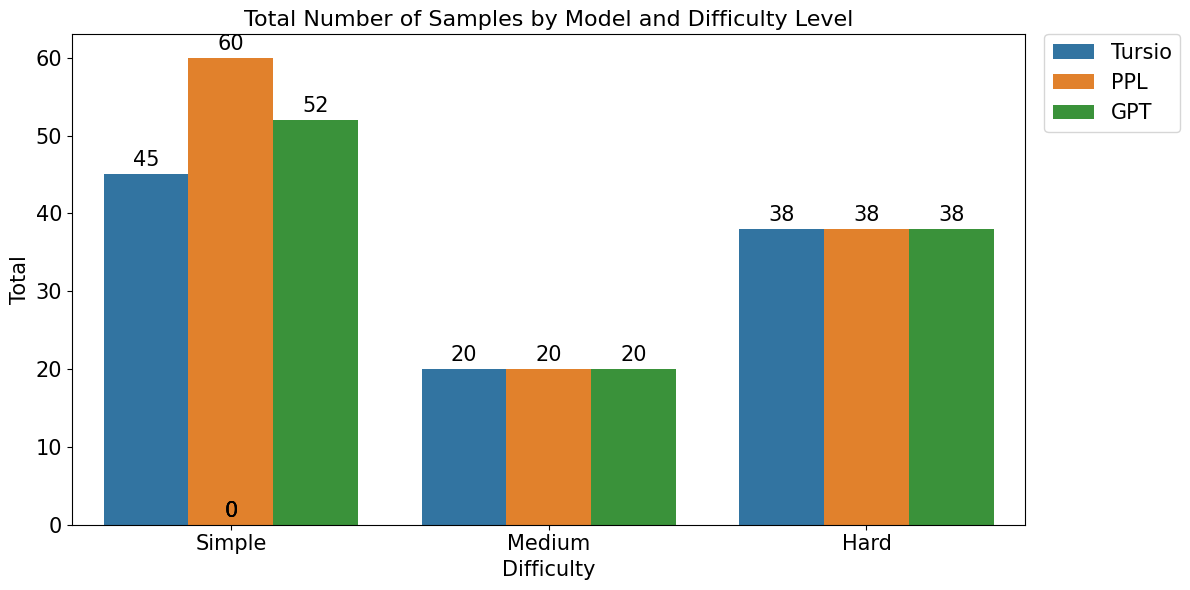

In [65]:
# plot total number of samples per model and difficulty level
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=summary, x="Difficulty", y="Total", hue="Model")
plt.title("Total Number of Samples by Model and Difficulty Level", fontsize=16)
plt.xlabel("Difficulty", fontsize=15)
plt.ylabel("Total", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=15, title_fontsize=15)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points',
        fontsize=15
    )
plt.tight_layout()
plt.savefig("eval_reports/total_samples_per_model_difficulty.png")
plt.show()

In [66]:
run_stats_tests(summary)

---- Simple ----
The difference between Tursio and GPT for Simple difficulty is not statistically significant (p = 1.0000).
The difference between Tursio and PPL for Simple difficulty is not statistically significant (p = 1.0000).
---- Medium ----
The difference between Tursio and GPT for Medium difficulty is not statistically significant (p = 0.4682).
The difference between Tursio and PPL for Medium difficulty is not statistically significant (p = 1.0000).
---- Hard ----
The difference between Tursio and GPT for Hard difficulty is not statistically significant (p = 0.1233).
The difference between Tursio and PPL for Hard difficulty is not statistically significant (p = 0.1233).


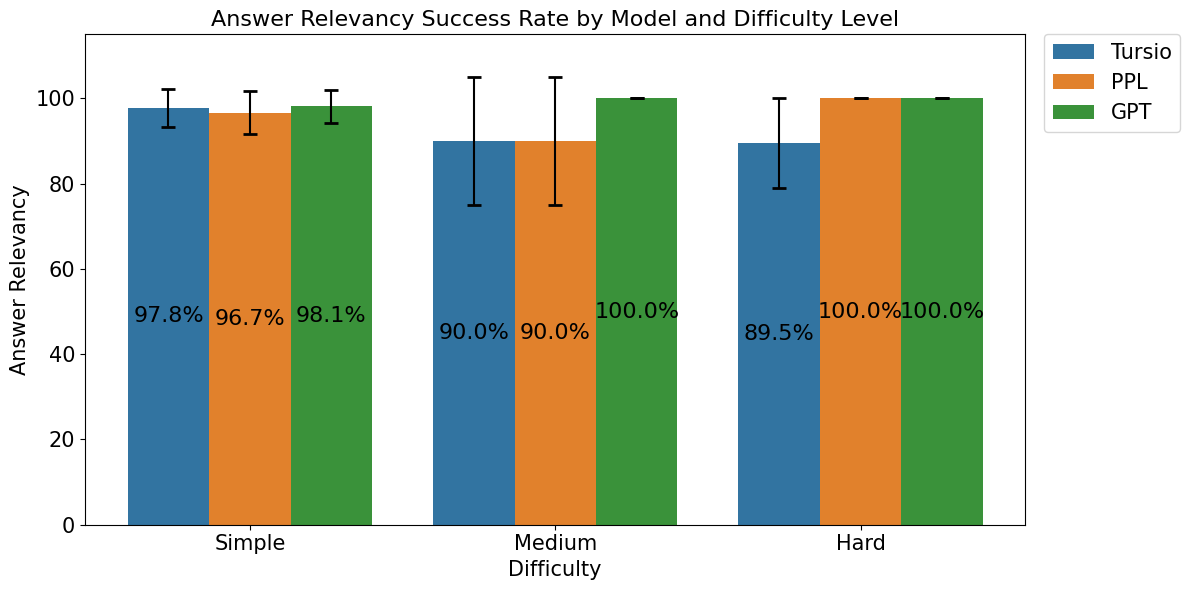

In [67]:
plot_summary(summary)

/var/folders/tp/6s73frhj1p5f5qtl575l8bm00000gn/T/ipykernel_12270/1922293265.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["metric_success"] = df["metric_score"] >= threshold
/var/folders/tp/6s73frhj1p5f5qtl575l8bm00000gn/T/ipykernel_12270/1922293265.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([summary, pd.DataFrame({"Dataset": [name], "Total": [total], "Success": [success], "Answer Relevancy": [success_rate]})], ignore_index=True)
/var/folders/tp/6s73frhj1p5f5qtl

---- Simple ----
The difference between Tursio and GPT for Simple difficulty is not statistically significant (p = 0.5594).
The difference between Tursio and PPL for Simple difficulty is not statistically significant (p = 0.2357).
---- Medium ----
The difference between Tursio and GPT for Medium difficulty is statistically significant (p = 0.0231).
The difference between Tursio and PPL for Medium difficulty is not statistically significant (p = 0.0679).
---- Hard ----
The difference between Tursio and GPT for Hard difficulty is statistically significant (p = 0.0334).
The difference between Tursio and PPL for Hard difficulty is not statistically significant (p = 0.1126).


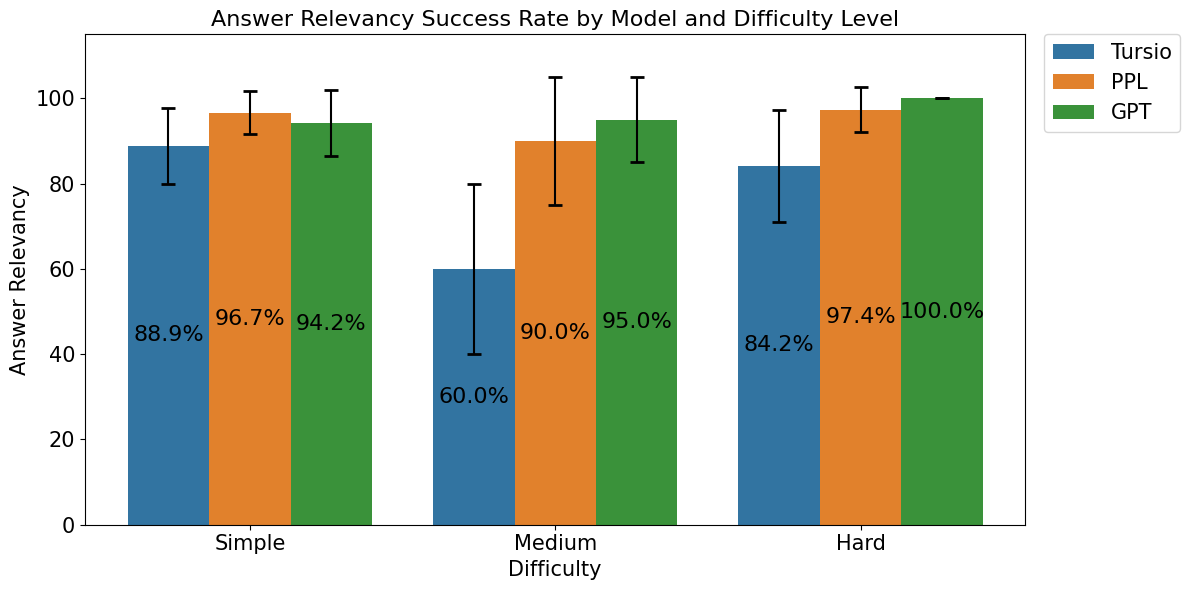

In [60]:
summary_7 = build_summary(threshold=0.7)
run_stats_tests(summary_7)
plot_summary(summary_7)